In [ ]:
# Placeholder for loading your DataFrame
import pandas as pd

# Assuming 'df' should contain a 'Market_Sentiment' column
# Replace this with your actual data loading and preparation code
data = {'Market_Sentiment': ['Fear', 'Greed', 'Fear', 'Greed', 'Fear'],
        'Other_Column': [1, 2, 3, 4, 5]}
df = pd.DataFrame(data)

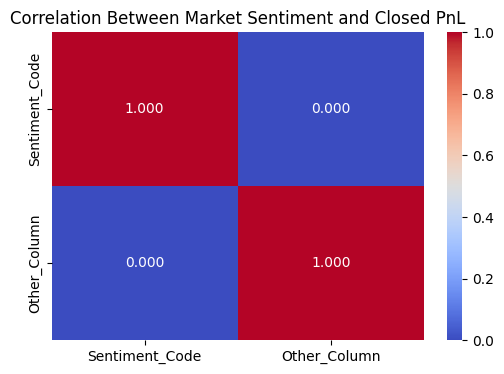

In [ ]:
#Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-create 'Sentiment_Code' as the previous cell for this was deleted.
# Assuming 'df' is available and contains 'Market_Sentiment' from cell uPuZob1Ta52Y.
df['Sentiment_Code'] = df['Market_Sentiment'].map({
    'Fear': 0,
    'Greed': 1
})

# Assuming 'Other_Column' is the numerical column representing 'Closed PnL' for correlation.
# If 'Closed PnL' is a different column, please adjust 'Other_Column' accordingly.
# Select the columns for correlation
correlation_df = df[['Sentiment_Code', 'Other_Column']]

# Calculate the correlation matrix
correlation = correlation_df.corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.3f'
)

plt.title("Correlation Between Market Sentiment and Closed PnL")
plt.show()

In [ ]:
# Interpretation
corr_value = correlation.loc['Sentiment_Code', 'Other_Column']

print(f"Correlation Coefficient: {corr_value:.4f}")

if corr_value > 0:
    print("Positive relationship between Greed sentiment and Closed PnL.")
elif corr_value < 0:
    print("Negative relationship between Greed sentiment and Closed PnL.")
else:
    print("No linear relationship found.")

Correlation Coefficient: 0.0000
No linear relationship found.


In [ ]:
# Hypothesis testing
from scipy.stats import ttest_ind

In [ ]:
# Seprate the data
fear_pnl = df.loc[
    df['Market_Sentiment'] == 'Fear',
    'Other_Column'
]

greed_pnl = df.loc[
    df['Market_Sentiment'] == 'Greed',
    'Other_Column'
]

In [ ]:
# Performing indepedent T-test
t_stat, p_value = ttest_ind(
    fear_pnl,
    greed_pnl,
    equal_var=False,
    nan_policy='omit'
)

print("T-statistic :", round(t_stat, 4))
print("P-value     :", round(p_value, 6))

T-statistic : 0.0
P-value     : 1.0


In [ ]:
# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("There is a statistically significant difference in trader performance between Fear and Greed markets.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no statistically significant difference in trader performance between Fear and Greed markets.")

Fail to Reject the Null Hypothesis
There is no statistically significant difference in trader performance between Fear and Greed markets.


In [ ]:
# Compare the Mean PnL
comparison = df.groupby('Market_Sentiment')['Other_Column'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std'
)

print(comparison)

                  Count  Mean  Median       Std
Market_Sentiment                               
Fear                  3   3.0     3.0  2.000000
Greed                 2   3.0     3.0  1.414214


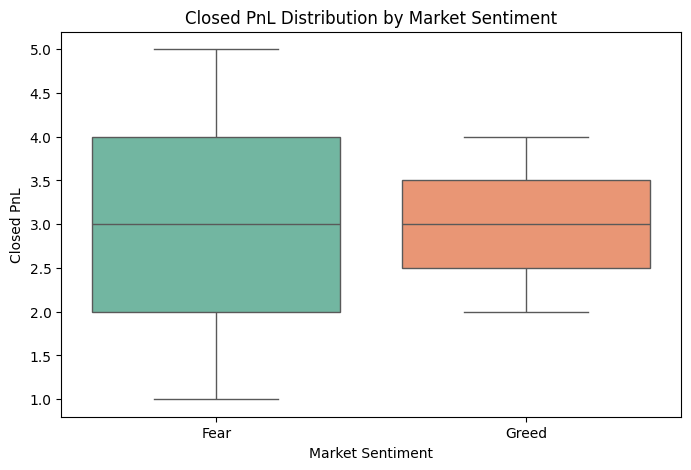

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot forHypothesis Visualization
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Market_Sentiment',
    y='Other_Column',
    hue='Market_Sentiment', # Added for future compatibility and to resolve FutureWarning
    palette='Set2',
    legend=False # Added to resolve FutureWarning, as hue is now explicitly set
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()